In [393]:
import pandas as pd

In [394]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]
df_train = pd.read_csv('adult.data', names=columns)
df_test = pd.read_csv('adult.test', names=columns)

In [395]:
df_test.dropna(inplace=True)

In [396]:
df_test['income'] = df_test['income'].str.replace('.', '', regex=False).str.strip()
df_train['income'] = df_train['income'].str.replace('.', '', regex=False).str.strip()

In [397]:
df_test.isnull().sum().sort_values(ascending=False)

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [398]:
df_train.isnull().sum().sort_values(ascending=False)

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [399]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
df_train['income']=label.fit_transform(df_train['income'])
df_test['income']=label.transform(df_test['income'])

In [400]:
df_train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [401]:
df_test.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,0
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,0
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,1
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,1
5,18,?,103497.0,Some-college,10.0,Never-married,?,Own-child,White,Female,0.0,0.0,30.0,United-States,0


In [402]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 3.7+ MB


In [403]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16281 entries, 1 to 16281
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             16281 non-null  object 
 1   workclass       16281 non-null  object 
 2   fnlwgt          16281 non-null  float64
 3   education       16281 non-null  object 
 4   education-num   16281 non-null  float64
 5   marital-status  16281 non-null  object 
 6   occupation      16281 non-null  object 
 7   relationship    16281 non-null  object 
 8   race            16281 non-null  object 
 9   sex             16281 non-null  object 
 10  capital-gain    16281 non-null  float64
 11  capital-loss    16281 non-null  float64
 12  hours-per-week  16281 non-null  float64
 13  native-country  16281 non-null  object 
 14  income          16281 non-null  int64  
dtypes: float64(5), int64(1), object(9)
memory usage: 2.0+ MB


In [404]:
df_train.shape, df_test.shape

((32561, 15), (16281, 15))

In [405]:
df_train.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

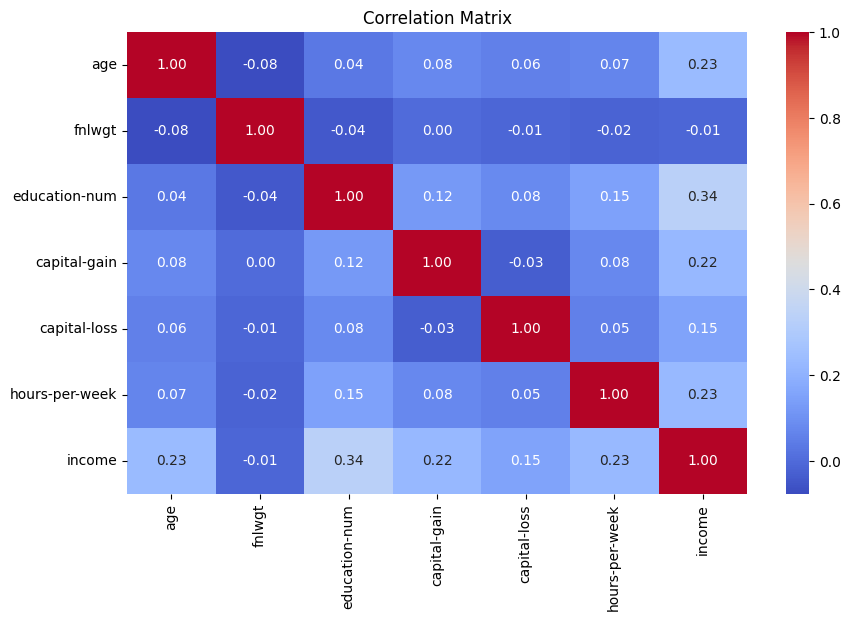

In [406]:
import seaborn as sns   
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,6))
corr=df_train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

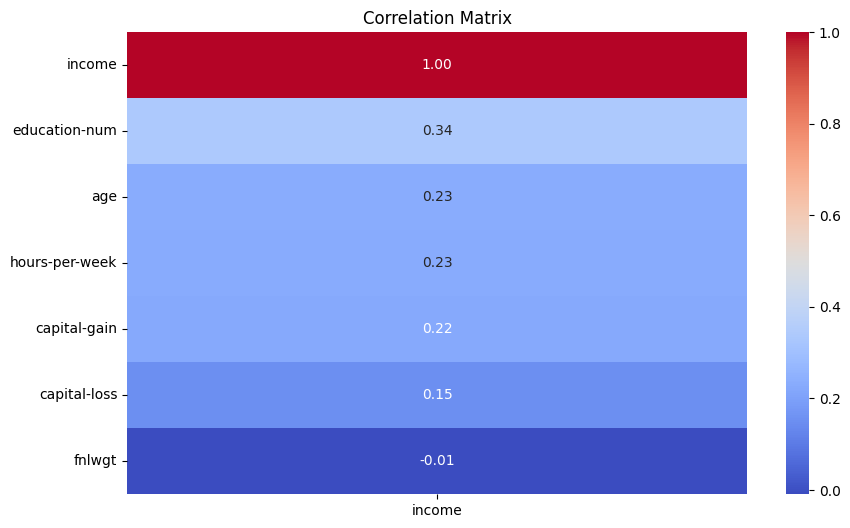

In [407]:
import seaborn as sns   
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,6))
corr=df_train.corr(numeric_only=True)
sns.heatmap(corr[['income']].sort_values(by='income',ascending=False), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [408]:
df_train['income'].value_counts()

income
0    24720
1     7841
Name: count, dtype: int64

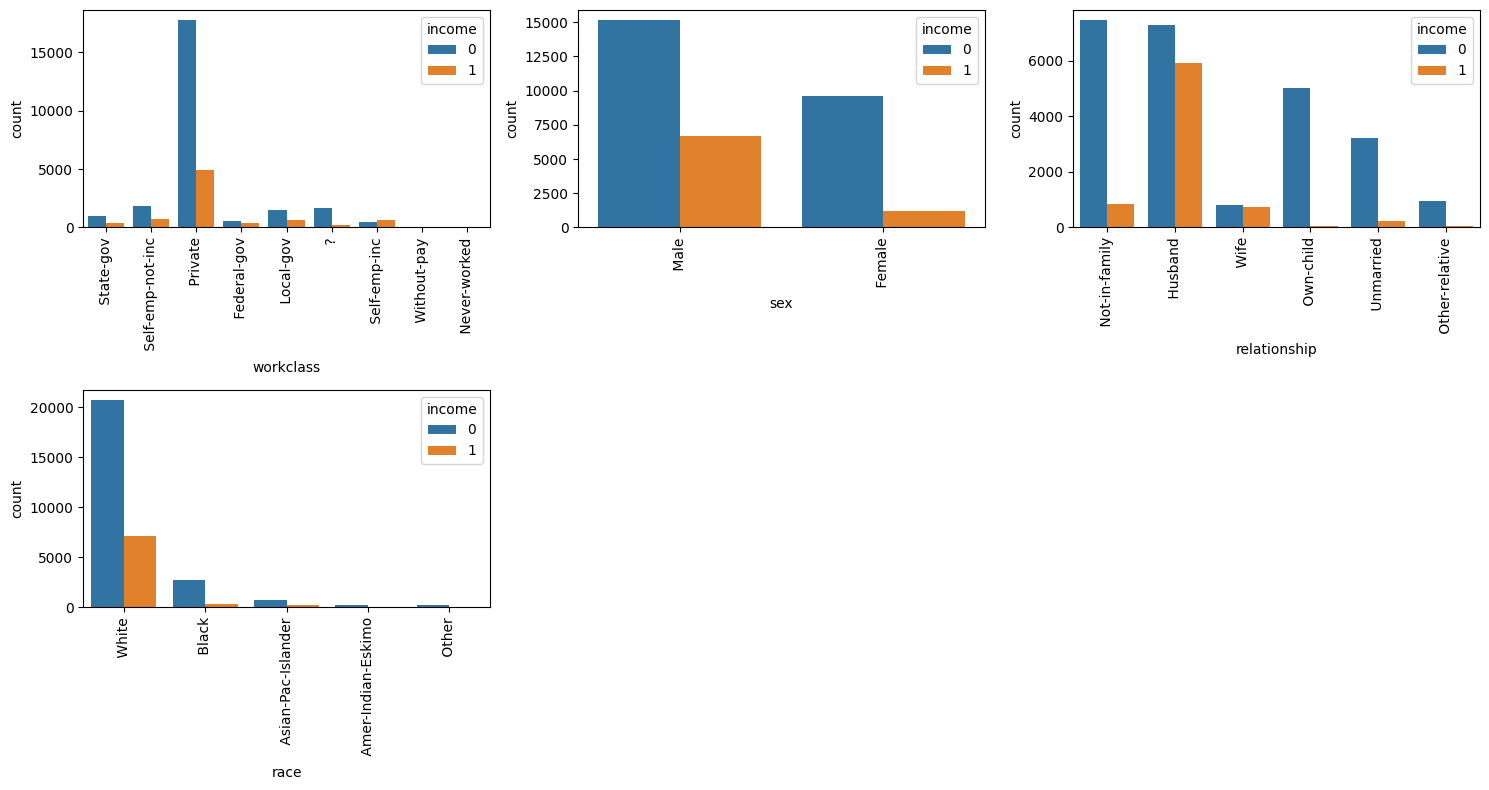

In [409]:
plt.figure(figsize=(15,8))
plt.subplot(2,3,1)
sns.countplot(x=df_train['workclass'],hue=df_train['income'])
plt.xticks(rotation=90)
plt.subplot(2,3,2)
sns.countplot(x=df_train['sex'],hue=df_train['income'])
plt.xticks(rotation=90)
plt.subplot(2,3,3)
sns.countplot(x=df_train['relationship'],hue=df_train['income'])
plt.xticks(rotation=90)
plt.subplot(2,3,4)
sns.countplot(x=df_train['race'],hue=df_train['income'])
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [410]:
ccat=df_test.select_dtypes(include='object').columns
for c in ccat:
   print(c)
   print(df_test[c].unique())

age
['25' '38' '28' '44' '18' '34' '29' '63' '24' '55' '65' '36' '26' '58'
 '48' '43' '20' '37' '40' '72' '45' '22' '23' '54' '32' '46' '56' '17'
 '39' '52' '21' '42' '33' '30' '47' '41' '19' '69' '50' '31' '59' '49'
 '51' '27' '57' '61' '64' '79' '73' '53' '77' '80' '62' '35' '68' '66'
 '75' '60' '67' '71' '70' '90' '81' '74' '78' '82' '83' '85' '76' '84'
 '89' '88' '87']
workclass
[' Private' ' Local-gov' ' ?' ' Self-emp-not-inc' ' Federal-gov'
 ' State-gov' ' Self-emp-inc' ' Without-pay' ' Never-worked']
education
[' 11th' ' HS-grad' ' Assoc-acdm' ' Some-college' ' 10th' ' Prof-school'
 ' 7th-8th' ' Bachelors' ' Masters' ' Doctorate' ' 5th-6th' ' Assoc-voc'
 ' 9th' ' 12th' ' 1st-4th' ' Preschool']
marital-status
[' Never-married' ' Married-civ-spouse' ' Widowed' ' Divorced'
 ' Separated' ' Married-spouse-absent' ' Married-AF-spouse']
occupation
[' Machine-op-inspct' ' Farming-fishing' ' Protective-serv' ' ?'
 ' Other-service' ' Prof-specialty' ' Craft-repair' ' Adm-clerical'
 ' Exec

In [411]:
# df_train[df_train['workclass']==' ?'].head(10)
ccat=df_train.select_dtypes(include='object').columns
for c in ccat:
   print(c)
   print(df_train[c].unique())


workclass
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
education
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
marital-status
[' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
occupation
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' ' ?'
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv']
relationship
[' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']
race
[' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other']
sex
[' Male' ' Female']
native-country
[' United-States' ' Cuba' ' Jamaica' ' India' '

In [444]:
   # country
   # workcass
   # occuption
df_train=df_train[(df_train['native-country']!=' ?')& (df_train['workclass']!=' ?')& (df_train['occupation']!=' ?')]
df_test=df_test[(df_test['native-country']!=' ?')& (df_test['workclass']!=' ?')& (df_test['occupation']!=' ?')]

In [445]:
ccat=df_train.select_dtypes(include='object').columns
for c in ccat:
   print(c)
   print(df_train[c].unique())

workclass
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' Self-emp-inc' ' Without-pay']
education
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' 7th-8th' ' Doctorate' ' Assoc-voc' ' Prof-school'
 ' 5th-6th' ' 10th' ' Preschool' ' 12th' ' 1st-4th']
marital-status
[' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
occupation
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Transport-moving' ' Farming-fishing'
 ' Machine-op-inspct' ' Tech-support' ' Craft-repair' ' Protective-serv'
 ' Armed-Forces' ' Priv-house-serv']
relationship
[' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']
race
[' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other']
sex
[' Male' ' Female']
native-country
[' United-States' ' Cuba' ' Jamaica' ' India' ' Mexico' ' Puerto-Rico'
 '

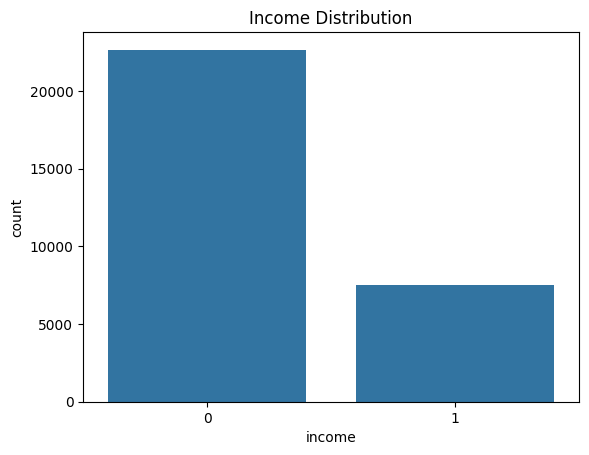

In [446]:
sns.countplot(x=df_train['income'])
plt.title('Income Distribution')
plt.show()

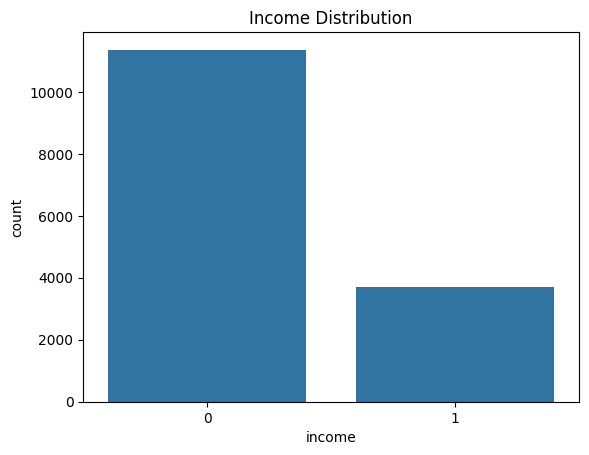

In [447]:
sns.countplot(x=df_test['income'])
plt.title('Income Distribution')
plt.show()

In [448]:
X_train = df_train.drop('income', axis=1)
y_train = df_train['income']   
X_test = df_test.drop('income', axis=1)
y_test = df_test['income']

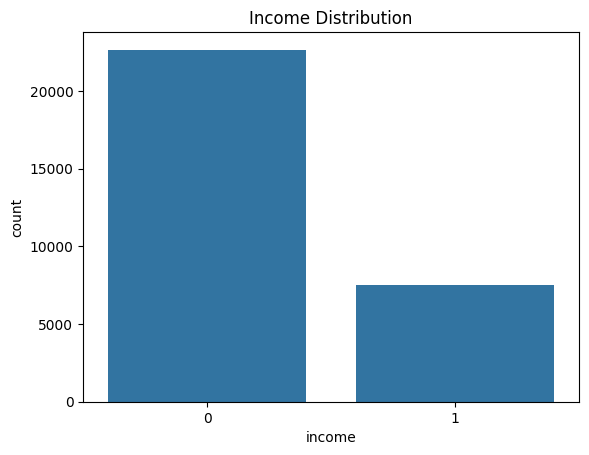

In [449]:
sns.countplot(x=df_train['income'])
plt.title('Income Distribution')
plt.show()

In [450]:
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, StandardScaler
num_pip = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [451]:
cat_pip = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),   
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [452]:
num=X_train.select_dtypes(exclude='object').columns
cat=X_train.select_dtypes(include='object').columns

In [453]:
df=ColumnTransformer(transformers=[
    ('num', num_pip, num),
    ('cat', cat_pip, cat)
])

In [454]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import AdaBoostClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier    

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree (ID3)': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(),
    'LightGBM': LGBMClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0,random_state=42)
}

In [455]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
for mode_name,model_per in models.items():
    pipe=Pipeline(steps=[
        ('preprocessor', df),
        ('classifier', model_per)
    ])
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    print(f'{mode_name} : {acc*100:.2f}%')

Logistic Regression : 84.76%
Decision Tree (ID3) : 80.42%
Random Forest : 84.71%
AdaBoost : 84.85%
XGBoost : 86.85%
[LightGBM] [Info] Number of positive: 7508, number of negative: 22654
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 767
[LightGBM] [Info] Number of data points in the train set: 30162, number of used features: 91
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.248922 -> initscore=-1.104367
[LightGBM] [Info] Start training from score -1.104367


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM : 86.90%
CatBoost : 87.04%


In [456]:
md=Pipeline(steps=[
  ('preprcess',df),
  ('model',LGBMClassifier(random_state=42))  
])
md.fit(X_train,y_train)
y_pred=md.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)

[LightGBM] [Info] Number of positive: 7508, number of negative: 22654
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003639 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 767
[LightGBM] [Info] Number of data points in the train set: 30162, number of used features: 91
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.248922 -> initscore=-1.104367
[LightGBM] [Info] Start training from score -1.104367


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [457]:
accuracy

0.8689907038512616

In [458]:
md.score(X_train,y_train)

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.8858497447118892

confusion matrix <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000001A03C772470>
classifictain report               precision    recall  f1-score   support

           0       0.89      0.94      0.92     11360
           1       0.77      0.66      0.71      3700

    accuracy                           0.87     15060
   macro avg       0.83      0.80      0.81     15060
weighted avg       0.86      0.87      0.87     15060



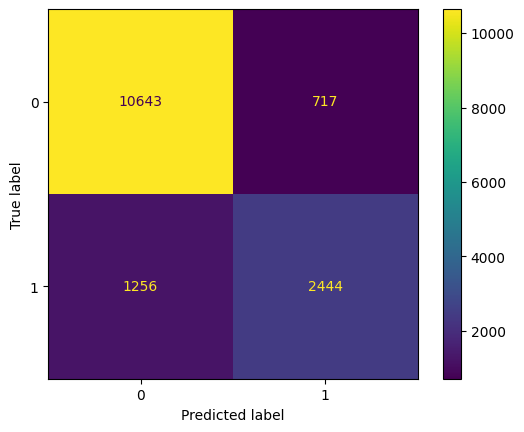

In [459]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print("confusion matrix",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
print("classifictain report",classification_report(y_test,y_pred))